# ABL Wake

In [1]:
import pblwake_keps_ABL as pblwake
import numpy as np
import matplotlib.pyplot as plt

# Set parameters

Grid points:  179
Num Steps:  89.0


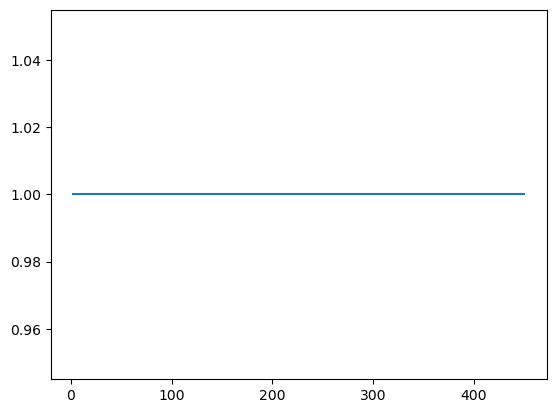

In [2]:
dz = 2.5
z1 = dz
z2 =  450 
N  = int(np.ceil((z2-z1)/dz))
zvec  = np.linspace(z1, z2, N) 

zhh    = 90
D      = 127
totalX = 7*D
dx_init = 10.0
#dx_init = 2.0
numSteps = np.ceil(totalX/dx_init)

fixed_dx = True
clipping = True
print("Grid points: ",N)
print("Num Steps: ",numSteps)

param = {\
    'C_mu' : 5.48**(-2),\
    #'C_mu' : 0.01,\
    'C_1e' : 1.176,\
    'C_2e' : 1.92,\
    'C_3e' : 0.033,\
    'sigma_k' : 1.0,\
    'sigma_e' : 1.3,\
    'beta' : 1.0/300.0,\
    'rho' : 1.225,\
    'nu' : 1.8e-5,\
    'Pr' : 0.7,\
    'cp' : 1006.43,\
    'z0' : 0.15,\
    #'ustar' : 0.289809,\
    'ustar' : 0.575652,\
    'L' : float('inf'),\
    #'L' : -231,
    'K' : 0.42,\
    'qw' : 0,\
    #'qw' : -38.0,\
    'Tw' : 300,
    'Re' : 1.0/1.47e-5,\
    'g' : -9.8,
    'z_height':15
}

f = pblwake.mod_func(zvec,param)
plt.plot(zvec,f)

# Set boundary and initial conditions

In [3]:

UBC = [{'type':'dirichlet', 'value':pblwake.init_U_ABL(z1,param)}, # Lower
       #{'type':'neumann', 'value':param['ustar']**2/1.47e-5},  # Upper
       #{'type':'dirichlet', 'value':10},
       #{'type':'dirichlet', 'value':10.0},  # Upper
       {'type':'neumann', 'value':0.0},  # Upper
      ]

KBC = [ {'type':'dirichlet', 'value':pblwake.init_k_ABL(z1,param)}, # Lower
        #{'type':'dirichlet', 'value':0.25},
        #{'type':'neumann', 'value':0.0},  # Upper
        {'type':'neumann', 'value':0.0},  # Upper
      ]

EBC = [ {'type':'dirichlet', 'value':pblwake.init_e_ABL(z1,param)}, # Lower
        #{'type':'dirichlet', 'value':0.05}, # Lower
        #{'type':'neumann', 'value':0.0},  # Upper
        {'type':'neumann', 'value':0.0},  # Upper
      ]

# Define the boundary conditions
T1 = param['Tw']
T2  = 1.0*T1
deltaT = (T1-T2)
TBC = [ {'type':'dirichlet', 'value':pblwake.init_T_ABL(z1,param)}, # Lower
        #{'type':'dirichlet', 'value':pblwake.init_linear_profile(zvec,T1,T2)[0]}, # Lower
        #{'type':'neumann', 'value':(T2-T1)/(z2-z1)},  # lower
        {'type':'neumann', 'value':0}
      ]

dW   = 0.4
WBC_down= {'z':zvec[-1], 'value':-dW}
WBC_up = {'z':zvec[-1], 'value':dW}
WBC_flat = {'z':zvec[-1], 'value':0.0}

BC_flat = {'u':UBC, 'w':WBC_flat, 'T':TBC, 'k':KBC,'e':EBC}
BC_up = {'u':UBC, 'w':WBC_up, 'T':TBC, 'k':KBC,'e':EBC}
BC_down = {'u':UBC, 'w':WBC_down, 'T':TBC, 'k':KBC,'e':EBC}


fileroot = './JRSE/XZprofiles/'
xloc = 1.0
w_xloc = -2.5
################################################################################
#Set flat initial conditions
Uinit_flat = pblwake.get_LES_profile(zvec,fileroot,'flat','wturb','u',xloc)
Winit_flat = pblwake.get_LES_profile(zvec,fileroot,'flat','wturb','w',w_xloc)
#Winit_flat = WBC_flat['value']*np.ones(N)
kinit_flat = pblwake.get_LES_profile(zvec,fileroot,'flat','wturb','k',xloc)
#Tinit = pblwake.init_linear_profile(zvec,T1,T2)
Tinit_flat = pblwake.get_LES_profile(zvec,fileroot,'flat','wturb','T',w_xloc)

einit_flat = pblwake.set_e_init(zvec,dz,Uinit_flat,kinit_flat,Winit_flat,param)

# Uinit_flat = pblwake.init_U_ABL(zvec,param)
# einit_flat = pblwake.init_e_ABL(zvec,param)
# kinit_flat = pblwake.init_k_ABL(zvec,param)


pblwake.applyBCs_to_vec(Uinit_flat,UBC[0],UBC[1],dz)
#pblwake.applyBCs_to_vec(Tinit_flat,TBC[0],TBC[1],dz)
pblwake.applyBCs_to_vec(kinit_flat,KBC[0],KBC[1],dz)
pblwake.applyBCs_to_vec(einit_flat,EBC[0],EBC[1],dz)
IC_flat = {'u':Uinit_flat,'w':Winit_flat,'k':kinit_flat,'e':einit_flat,'T':Tinit_flat}
################################################################################

################################################################################
#Set up initial conditions
Uinit_up = pblwake.get_LES_profile(zvec,fileroot,'updraft','wturb','u',xloc)
Winit_up = pblwake.get_LES_profile(zvec,fileroot,'updraft','wturb','w',w_xloc)
#Winit_up = WBC_up['value']*np.ones(N)
kinit_up = pblwake.get_LES_profile(zvec,fileroot,'updraft','wturb','k',xloc)
#Tinit = pblwake.init_linear_profile(zvec,T1,T2)
Tinit_up = pblwake.get_LES_profile(zvec,fileroot,'updraft','wturb','T',w_xloc)
einit_up = pblwake.set_e_init(zvec,dz,Uinit_up,kinit_up,Winit_up,param)

# Uinit_up = pblwake.init_U_ABL(zvec,param)
# einit_up = pblwake.init_e_ABL(zvec,param)
# kinit_up = pblwake.init_k_ABL(zvec,param)

pblwake.applyBCs_to_vec(Uinit_up,UBC[0],UBC[1],dz)
#pblwake.applyBCs_to_vec(Tinit_up,TBC[0],TBC[1],dz)
pblwake.applyBCs_to_vec(kinit_up,KBC[0],KBC[1],dz)
pblwake.applyBCs_to_vec(einit_up,EBC[0],EBC[1],dz)
IC_up = {'u':Uinit_up,'w':Winit_up,'k':kinit_up,'e':einit_up,'T':Tinit_up}
################################################################################

################################################################################
#Set down initial conditions
Uinit_down = pblwake.get_LES_profile(zvec,fileroot,'downdraft','wturb','u',xloc)
Winit_down = pblwake.get_LES_profile(zvec,fileroot,'downdraft','wturb','w',w_xloc)
#Winit_down = WBC_down['value']*np.ones(N)
kinit_down = pblwake.get_LES_profile(zvec,fileroot,'downdraft','wturb','k',xloc)
#Tinit = pblwake.init_linear_profile(zvec,T1,T2)
Tinit_down = pblwake.get_LES_profile(zvec,fileroot,'downdraft','wturb','T',w_xloc)
einit_down = pblwake.set_e_init(zvec,dz,Uinit_down,kinit_down,Winit_down,param)

# Uinit_down = pblwake.init_U_ABL(zvec,param)
# einit_down = pblwake.init_e_ABL(zvec,param)
# kinit_down = pblwake.init_k_ABL(zvec,param)

pblwake.applyBCs_to_vec(Uinit_down,UBC[0],UBC[1],dz)
#pblwake.applyBCs_to_vec(Tinit_down,TBC[0],TBC[1],dz)
pblwake.applyBCs_to_vec(kinit_down,KBC[0],KBC[1],dz)
pblwake.applyBCs_to_vec(einit_down,EBC[0],EBC[1],dz)
IC_down = {'u':Uinit_down,'w':Winit_down,'k':kinit_down,'e':einit_down,'T':Tinit_down}
################################################################################



Reading data:  ./JRSE/XZprofiles/flat_wturb_Uh_XZ_1.0.dat
Reading data:  ./JRSE/XZprofiles/flat_wturb_velocityz_avg_XZ_-2.5.dat
Reading data:  ./JRSE/XZprofiles/flat_wturb_TKE_XZ_1.0.dat
Reading data:  ./JRSE/XZprofiles/flat_wturb_temperature_avg_XZ_-2.5.dat
Reading data:  ./JRSE/XZprofiles/updraft_wturb_Uh_XZ_1.0.dat
Reading data:  ./JRSE/XZprofiles/updraft_wturb_velocityz_avg_XZ_-2.5.dat
Reading data:  ./JRSE/XZprofiles/updraft_wturb_TKE_XZ_1.0.dat
Reading data:  ./JRSE/XZprofiles/updraft_wturb_temperature_avg_XZ_-2.5.dat
Reading data:  ./JRSE/XZprofiles/downdraft_wturb_Uh_XZ_1.0.dat
Reading data:  ./JRSE/XZprofiles/downdraft_wturb_velocityz_avg_XZ_-2.5.dat
Reading data:  ./JRSE/XZprofiles/downdraft_wturb_TKE_XZ_1.0.dat
Reading data:  ./JRSE/XZprofiles/downdraft_wturb_temperature_avg_XZ_-2.5.dat


10 0
no lim found
no lim found


/ascldap/users/gyalla/.local/IPython/core/events.py:82: UserWarning: Glyph 11 () missing from current font.
  func(*args, **kwargs)
/ascldap/users/gyalla/.local/IPython/core/pylabtools.py:152: UserWarning: Glyph 11 () missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


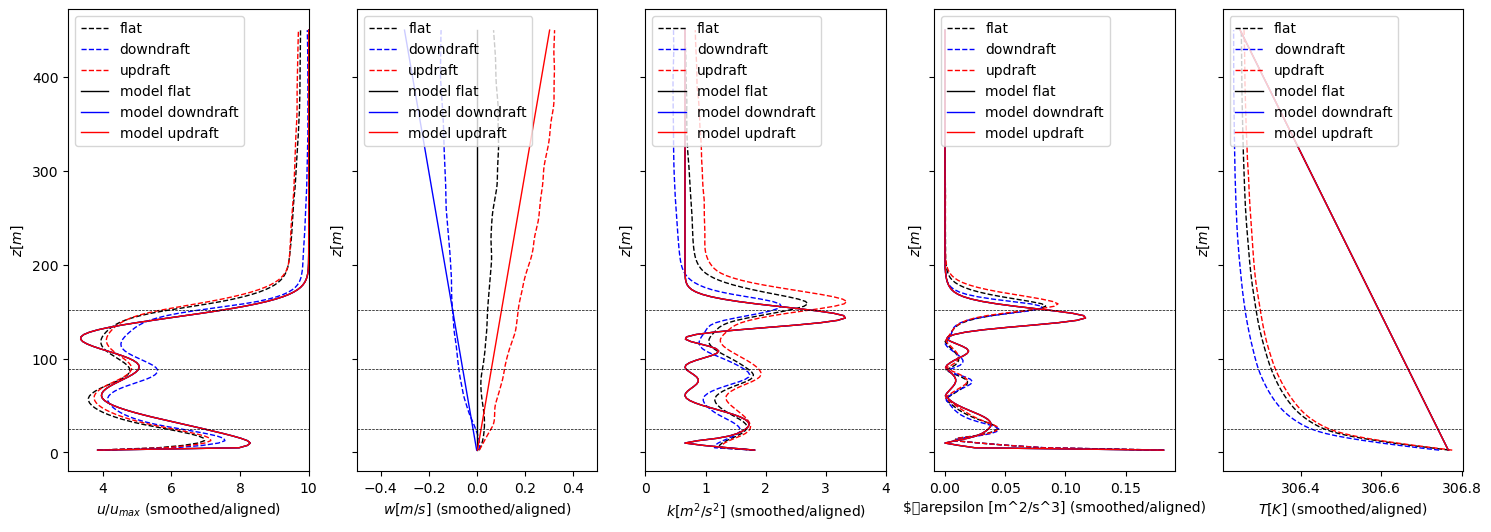

In [4]:
# Define parameters for the double Gaussian
x0_1 = 90-30  # Center position
x0_2 = 90+35  # Center position
sigma1 = 30.0  # Standard deviation of the first Gaussian
A1 = -6  # Amplitude of the first Gaussian
sigma2 = 20.0  # Standard deviation of the second Gaussian
A2 = -6  # Amplitude of the second Gaussian
yend   = IC_flat['u'][-1]
ystart = yend - IC_flat['u'][0]  

# x0_1 = 90-45  # Center position
# x0_2 = 90+35  # Center position
# sigma1 = 15.0  # Standard deviation of the first Gaussian
# A1 = -8  # Amplitude of the first Gaussian

# sigma2 = 15.0  # Standard deviation of the second Gaussian top
# A2 = -7  # Amplitude of the second Gaussian
# yend   = IC_flat['u'][-1]
# ystart = yend - IC_flat['u'][0]  

# Define parameters for the triple Gaussian
x0_1 = 90-30  # Center position
x0_2 = 90+35  # Center position
x0_3 = 0
sigma1 = 30.0  # Standard deviation of the first Gaussian
A1 = -6  # Amplitude of the first Gaussian
sigma2 = 20.0  # Standard deviation of the second Gaussian
A2 = -6  # Amplitude of the second Gaussian
sigma3 = 5.0  # Standard deviation of the second Gaussian
A3 = -1.5 # Amplitude of the second Gaussian
#yend   = IC_flat['u'][-1]
#ystart = yend - IC_flat['u'][0]  
yend   = 10
ystart = 0
print(yend,ystart)

# Generate the double Gaussian wake
#apply bcs to smooth profiles
WBC_flat= {'z':zvec[-1], 'value':0}
WBC_down= {'z':zvec[-1], 'value':-0.3}
WBC_up= {'z':zvec[-1], 'value':0.3}
Winit_flat = pblwake.init_linear_profile(zvec,0,0)
Winit_down = pblwake.init_linear_profile(zvec,0,-0.3)
Winit_up = pblwake.init_linear_profile(zvec,0,0.3)

model_U = pblwake.triple_gaussian(zvec, x0_1, x0_2,x0_3,sigma1, A1, sigma2, A2,sigma3,A3,ystart,yend)
#model_U = pblwake.double_gaussian(zvec, x0_1, x0_2,sigma1, A1, sigma2, A2)+yend
model_k= pblwake.set_k_init(zvec,dz,model_U,param,k_factor=2.0)+IC_flat['k'][-1]
pblwake.applyBCs_to_vec(model_k,KBC[0],KBC[1],dz)

model_e= pblwake.set_e_init(zvec,dz,model_U,model_k,Winit_flat,param)
model_e = np.clip(model_e, a_min=1e-5, a_max=None)
pblwake.applyBCs_to_vec(model_U,UBC[0],UBC[1],dz)
#model_U = pblwake.smooth_profile(model_U,window_size = 15)
#model_U = pblwake.smooth_profile_at_x(model_U,11,zvec,10)
pblwake.applyBCs_to_vec(model_U,UBC[0],UBC[1],dz)

pblwake.applyBCs_to_vec(model_k,KBC[0],KBC[1],dz)
pblwake.applyBCs_to_vec(model_e,EBC[0],EBC[1],dz)
#model_k = pblwake.smooth_profile(model_k,window_size = 11)
#model_e = pblwake.smooth_profile(model_e,window_size = 11)
pblwake.applyBCs_to_vec(model_k,KBC[0],KBC[1],dz)
pblwake.applyBCs_to_vec(model_e,EBC[0],EBC[1],dz)

T1=np.copy(IC_flat['T'][0])
T2=np.copy(IC_flat['T'][-1])
Tinit = pblwake.init_linear_profile(zvec,T1,T2)

IC_flat_smooth = {"u": model_U, "k":model_k,"e":model_e,"T":Tinit,"w":Winit_flat}
IC_down_smooth = {"u": model_U, "k":model_k,"e":model_e,"T":Tinit,"w":Winit_down}
IC_up_smooth = {"u": model_U, "k":model_k,"e":model_e,"T":Tinit,"w":Winit_up}

IC_flat_smooth['T']=np.copy(Tinit)
IC_down_smooth['T']=np.copy(Tinit)
IC_up_smooth['T']=np.copy(Tinit)
Tslope = (T2-T1)/(zvec[-1]-zvec[0])

TBC_flat = [ #{'type':'nuemann', 'value':(T2-T1)/(zvec[-1]-zvec[0])},
             #{'type':'nuemann', 'value':(T2-T1)/(zvec[-1]-zvec[0])}
             #{'type':'dirichlet', 'value':IC_flat_smooth['T'][0]},
             {'type':'neumann', 'value':Tslope},
             {'type':'neumann', 'value':Tslope}
             #{'type':'dirichlet', 'value':IC_flat_smooth['T'][-1]},
           ]
TBC_down = [ #{'type':'nuemann', 'value':(T2-T1)/(zvec[-1]-zvec[0])},
             #{'type':'nuemann', 'value':(T2-T1)/(zvec[-1]-zvec[0])}
             #{'type':'dirichlet', 'value':IC_down_smooth['T'][0]},
             {'type':'neumann', 'value':Tslope},
             {'type':'neumann', 'value':Tslope}
             #{'type':'dirichlet', 'value':IC_down_smooth['T'][-1]},
           ]
TBC_up = [  #{'type':'dirichlet', 'value':IC_up_smooth['T'][0]},
             {'type':'neumann', 'value':Tslope},
             {'type':'neumann', 'value':Tslope}
             #{'type':'dirichlet', 'value':IC_up_smooth['T'][-1]},
           ]

BC_flat = {'u':UBC, 'w':WBC_flat, 'T':TBC_flat, 'k':KBC,'e':EBC}
BC_down = {'u':UBC, 'w':WBC_down, 'T':TBC_down, 'k':KBC,'e':EBC}
BC_up   = {'u':UBC, 'w':WBC_up, 'T':TBC_up, 'k':KBC,'e':EBC}

pblwake.applyBCs_to_vec(IC_flat_smooth['u'],UBC[0],UBC[1],dz)
pblwake.applyBCs_to_vec(IC_flat_smooth['k'],KBC[0],KBC[1],dz)
pblwake.applyBCs_to_vec(IC_flat_smooth['e'],EBC[0],EBC[1],dz)
pblwake.applyBCs_to_vec(IC_flat_smooth['T'],TBC_flat[0],TBC_flat[1],dz)

pblwake.applyBCs_to_vec(IC_down_smooth['u'],UBC[0],UBC[1],dz)
pblwake.applyBCs_to_vec(IC_down_smooth['k'],KBC[0],KBC[1],dz)
pblwake.applyBCs_to_vec(IC_down_smooth['e'],EBC[0],EBC[1],dz)
pblwake.applyBCs_to_vec(IC_down_smooth['T'],TBC_down[0],TBC_down[1],dz)

pblwake.applyBCs_to_vec(IC_up_smooth['u'],UBC[0],UBC[1],dz)
pblwake.applyBCs_to_vec(IC_up_smooth['k'],KBC[0],KBC[1],dz)
pblwake.applyBCs_to_vec(IC_up_smooth['e'],EBC[0],EBC[1],dz)
pblwake.applyBCs_to_vec(IC_up_smooth['T'],TBC_up[0],TBC_up[1],dz)

fig, ax = plt.subplots(1,5, figsize=(18,6),sharey=True)
ax = ax.flatten()
colors ={'flat':'k','down':'blue','up':'red'}
titles = ['$u/u_{max}$','$w [m/s]$','$k [m^2/s^2]$','$\varepsilon [m^2/s^3]','$T [K]$']
lims = {'u':(3,10),'w':(-0.5,0.5),'k':(0,4)}
for iplt,prof in enumerate(IC_flat):
    ax[iplt].plot(IC_flat[prof],zvec,color=colors['flat'],ls='--',lw=1,label='flat')
    ax[iplt].plot(IC_down[prof],zvec,color=colors['down'],ls='--',lw=1,label='downdraft')
    ax[iplt].plot(IC_up[prof],zvec,color=colors['up'],ls='--',lw=1,label='updraft')

    ax[iplt].plot(IC_flat_smooth[prof],zvec,color=colors['flat'],ls='-',lw=1,label='model flat')
    ax[iplt].plot(IC_down_smooth[prof],zvec,color=colors['down'],ls='-',lw=1,label='model downdraft')
    ax[iplt].plot(IC_up_smooth[prof],zvec,color=colors['up'],ls='-',lw=1,label='model updraft')

    ax[iplt].set_xlabel(titles[iplt]+ " (smoothed/aligned)")

    ax[iplt].set_ylabel("$z [m]$")

    ax[iplt].legend(loc=2)

    try:
        ax[iplt].set_xlim(lims[prof])
    except:
        print("no lim found")
for i in range(0,len(ax)):
    hub = 88.5
    ax[i].axhline(hub-D/2,c='k',ls='--',lw=0.5)
    ax[i].axhline(hub+D/2,c='k',ls='--',lw=0.5)
    ax[i].axhline(hub,c='k',ls='--',lw=0.5)



#the next step is to apply the BCs to vec and smooth using the same parameters as above


no lim found
no lim found


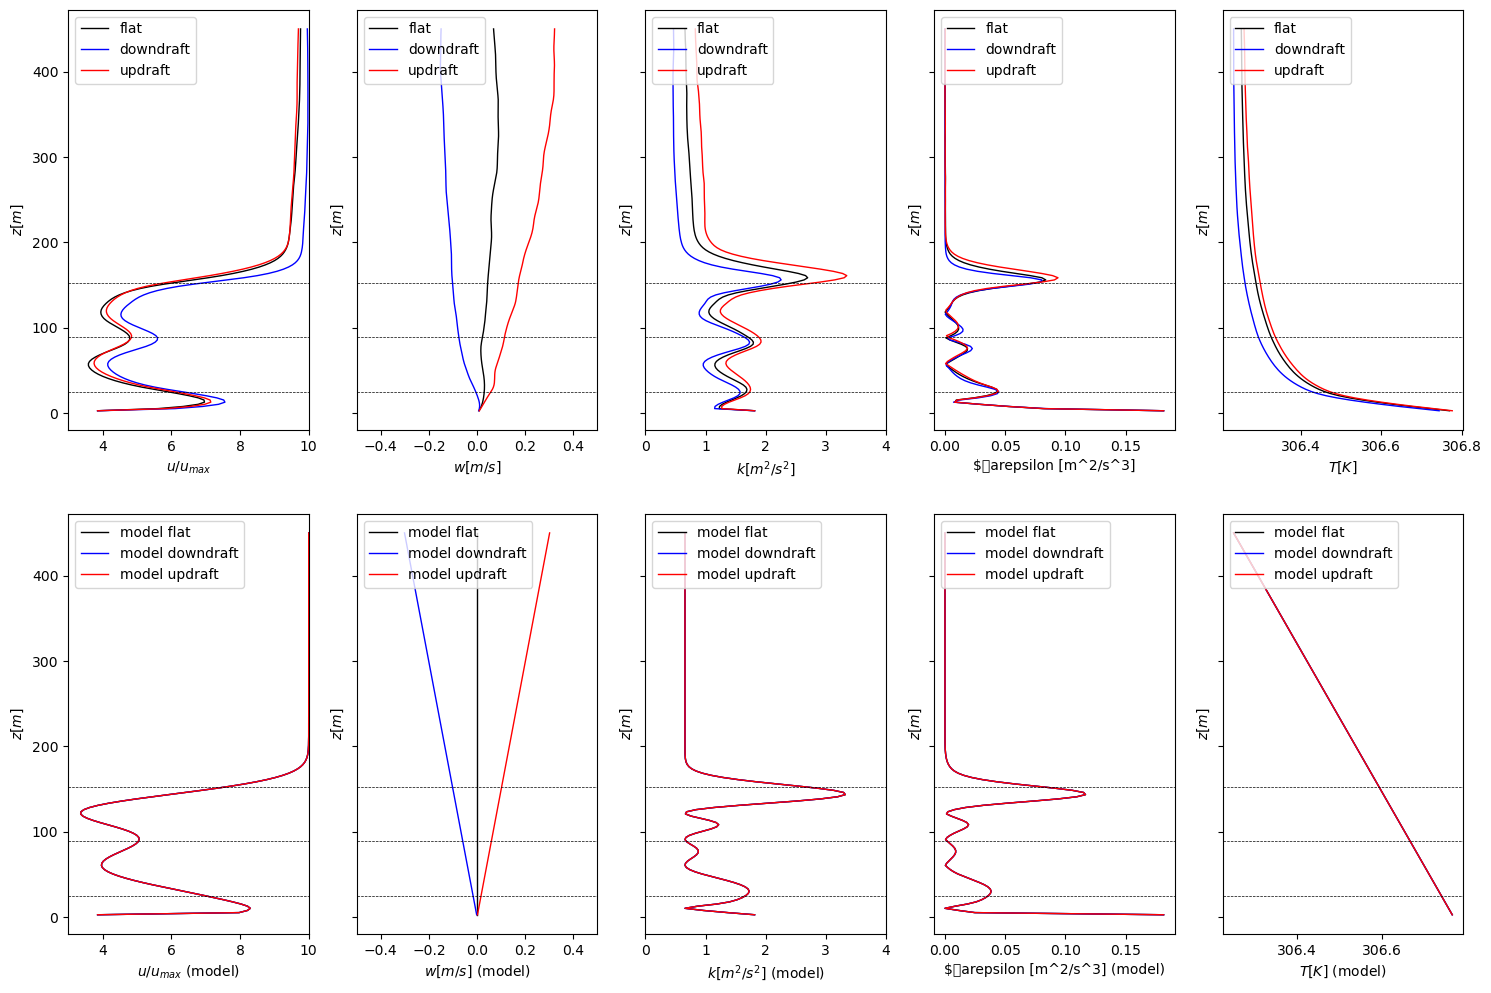

In [5]:

fig, ax = plt.subplots(2,5, figsize=(18,12),sharey=True)
ax = ax.flatten()
colors ={'flat':'k','down':'blue','up':'red'}
titles = ['$u/u_{max}$','$w [m/s]$','$k [m^2/s^2]$','$\varepsilon [m^2/s^3]','$T [K]$']
lims = {'u':(3,10),'w':(-0.5,0.5),'k':(0,4)}
for iplt,prof in enumerate(IC_flat):
    ax[iplt].plot(IC_flat[prof],zvec,color=colors['flat'],lw=1,label='flat')
    ax[iplt+5].plot(IC_flat_smooth[prof],zvec,color=colors['flat'],ls='-',lw=1,label='model flat')

    ax[iplt].plot(IC_down[prof],zvec,color=colors['down'],lw=1,label='downdraft')
    ax[iplt+5].plot(IC_down_smooth[prof],zvec,color=colors['down'],ls='-',lw=1,label='model downdraft')

    ax[iplt].plot(IC_up[prof],zvec,color=colors['up'],lw=1,label='updraft')
    ax[iplt+5].plot(IC_up_smooth[prof],zvec,color=colors['up'],ls='-',lw=1,label='model updraft')

    ax[iplt].set_xlabel(titles[iplt])
    ax[iplt+5].set_xlabel(titles[iplt]+ " (model)")

    ax[iplt].set_ylabel("$z [m]$")
    ax[iplt+5].set_ylabel("$z [m]$")

    ax[iplt].legend(loc=2)
    ax[iplt+5].legend(loc=2)

    try:
        ax[iplt].set_xlim(lims[prof])
        ax[iplt+5].set_xlim(lims[prof])
    except:
        print("no lim found")
for i in range(0,len(ax)):
    hub = 88.5
    ax[i].axhline(hub-D/2,c='k',ls='--',lw=0.5)
    ax[i].axhline(hub+D/2,c='k',ls='--',lw=0.5)
    ax[i].axhline(hub,c='k',ls='--',lw=0.5)

In [6]:
# Solve various solutions

Uvec_flat , Wvec_flat , Tvec_flat , kvec_flat , evec_flat ,xvec_flat   = pblwake.marchWakeBL(IC_flat_smooth, numSteps , zvec, param, BC_flat,dx_init=dx_init,fixed_dx=fixed_dx,clipping=clipping,verbose=False)
Sol_flat = {'u':Uvec_flat,'w':Wvec_flat,'k':kvec_flat,'e':evec_flat,'T':Tvec_flat}

Working on step:  0 , dx:  10.0 prev residual:  100
Working on step:  1 , dx:  10.0 prev residual:  100


Working on step:  2 , dx:  10.0 prev residual:  6.047394157661984
Working on step:  3 , dx:  10.0 prev residual:  3.1546861753426865
Working on step:  4 , dx:  10.0 prev residual:  1.849459621964262
Working on step:  5 , dx:  10.0 prev residual:  1.3276521967645856
Working on step:  6 , dx:  10.0 prev residual:  1.0529302032138221
Working on step:  7 , dx:  10.0 prev residual:  0.8977325345222277
Working on step:  8 , dx:  10.0 prev residual:  0.7915165628097965
Working on step:  9 , dx:  10.0 prev residual:  0.7119140705610154
Working on step:  10 , dx:  10.0 prev residual:  0.6498872139690839
Working on step:  11 , dx:  10.0 prev residual:  0.6001616119366975
Working on step:  12 , dx:  10.0 prev residual:  0.5593719201967469
Working on step:  13 , dx:  10.0 prev residual:  0.5252520636126314
Working on step:  14 , dx:  10.0 prev residual:  0.49621194776759125
Working on step:  15 , dx:  10.0 prev residual:  0.4711134379617299
Working on step:  16 , dx:  10.0 prev residual:  0.449128

In [7]:

Uvec_up , Wvec_up , Tvec_up , kvec_up , evec_up ,xvec_up   = pblwake.marchWakeBL(IC_up_smooth, numSteps , zvec, param, BC_up,dx_init=dx_init,fixed_dx=fixed_dx,clipping=clipping,verbose=False)
Sol_up = {'u':Uvec_up,'w':Wvec_up,'k':kvec_up,'e':evec_up,'T':Tvec_up}



Working on step:  0 , dx:  10.0 prev residual:  100
Working on step:  1 , dx:  10.0 prev residual:  100


Working on step:  2 , dx:  10.0 prev residual:  7.467132321732541
Working on step:  3 , dx:  10.0 prev residual:  3.381916611707764
Working on step:  4 , dx:  10.0 prev residual:  2.1134793326946477
Working on step:  5 , dx:  10.0 prev residual:  1.6137969785019484
Working on step:  6 , dx:  10.0 prev residual:  1.3336580304573378
Working on step:  7 , dx:  10.0 prev residual:  1.1679169004064873
Working on step:  8 , dx:  10.0 prev residual:  1.0512071376650516
Working on step:  9 , dx:  10.0 prev residual:  0.9621998051644141
Working on step:  10 , dx:  10.0 prev residual:  0.8916807119875086
Working on step:  11 , dx:  10.0 prev residual:  0.8341705204701256
Working on step:  12 , dx:  10.0 prev residual:  0.7861552196044378
Working on step:  13 , dx:  10.0 prev residual:  0.7452679430848803
Working on step:  14 , dx:  10.0 prev residual:  0.7098561308671848
Working on step:  15 , dx:  10.0 prev residual:  0.678740542764035
Working on step:  16 , dx:  10.0 prev residual:  0.65106106

In [8]:

Uvec_down , Wvec_down , Tvec_down , kvec_down , evec_down ,xvec_down   = pblwake.marchWakeBL(IC_down_smooth, numSteps , zvec, param, BC_down,dx_init=dx_init,fixed_dx=fixed_dx,clipping=clipping,verbose=False)
Sol_down = {'u':Uvec_down,'w':Wvec_down,'k':kvec_down,'e':evec_down,'T':Tvec_down}

Working on step:  0 , dx:  10.0 prev residual:  100
Working on step:  1 , dx:  10.0 prev residual:  100


Working on step:  2 , dx:  10.0 prev residual:  6.130756858074317
Working on step:  3 , dx:  10.0 prev residual:  3.1768539353711094
Working on step:  4 , dx:  10.0 prev residual:  1.7624181646827928
Working on step:  5 , dx:  10.0 prev residual:  1.197835508882498
Working on step:  6 , dx:  10.0 prev residual:  0.9514055268845276
Working on step:  7 , dx:  10.0 prev residual:  0.8184477935366247
Working on step:  8 , dx:  10.0 prev residual:  0.7318819244560557
Working on step:  9 , dx:  10.0 prev residual:  0.668611516877349
Working on step:  10 , dx:  10.0 prev residual:  0.620141965911178
Working on step:  11 , dx:  10.0 prev residual:  0.5817270249239725
Working on step:  12 , dx:  10.0 prev residual:  0.5504585451677794
Working on step:  13 , dx:  10.0 prev residual:  0.5244580742165487
Working on step:  14 , dx:  10.0 prev residual:  0.5024626945895544
Working on step:  15 , dx:  10.0 prev residual:  0.48358823022061287
Working on step:  16 , dx:  10.0 prev residual:  0.46719938

In [9]:
def plotrotorlines(ax, zhh, rotorD, xstart, xend, **kwargs):
    ax.hlines(zhh,             xstart, xend, linewidth=1.0, **kwargs) 
    ax.hlines(zhh+rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) 
    ax.hlines(zhh-rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs)
    return

def setfigtextsize(ax, fsize):
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label, ax.yaxis.get_offset_text()] + ax.get_xticklabels() + ax.get_yticklabels() ):
        item.set_fontsize(fsize)

Saving JRSE_RANS_figs//RANS_profile_u.png
Saving JRSE_RANS_figs//RANS_profile_u.pdf
Saving JRSE_RANS_figs//RANS_profile_w.png
Saving JRSE_RANS_figs//RANS_profile_w.pdf
Saving JRSE_RANS_figs//RANS_profile_k.png
Saving JRSE_RANS_figs//RANS_profile_k.pdf
Saving JRSE_RANS_figs//RANS_profile_e.png
Saving JRSE_RANS_figs//RANS_profile_e.pdf
Saving JRSE_RANS_figs//RANS_profile_T.png
Saving JRSE_RANS_figs//RANS_profile_T.pdf


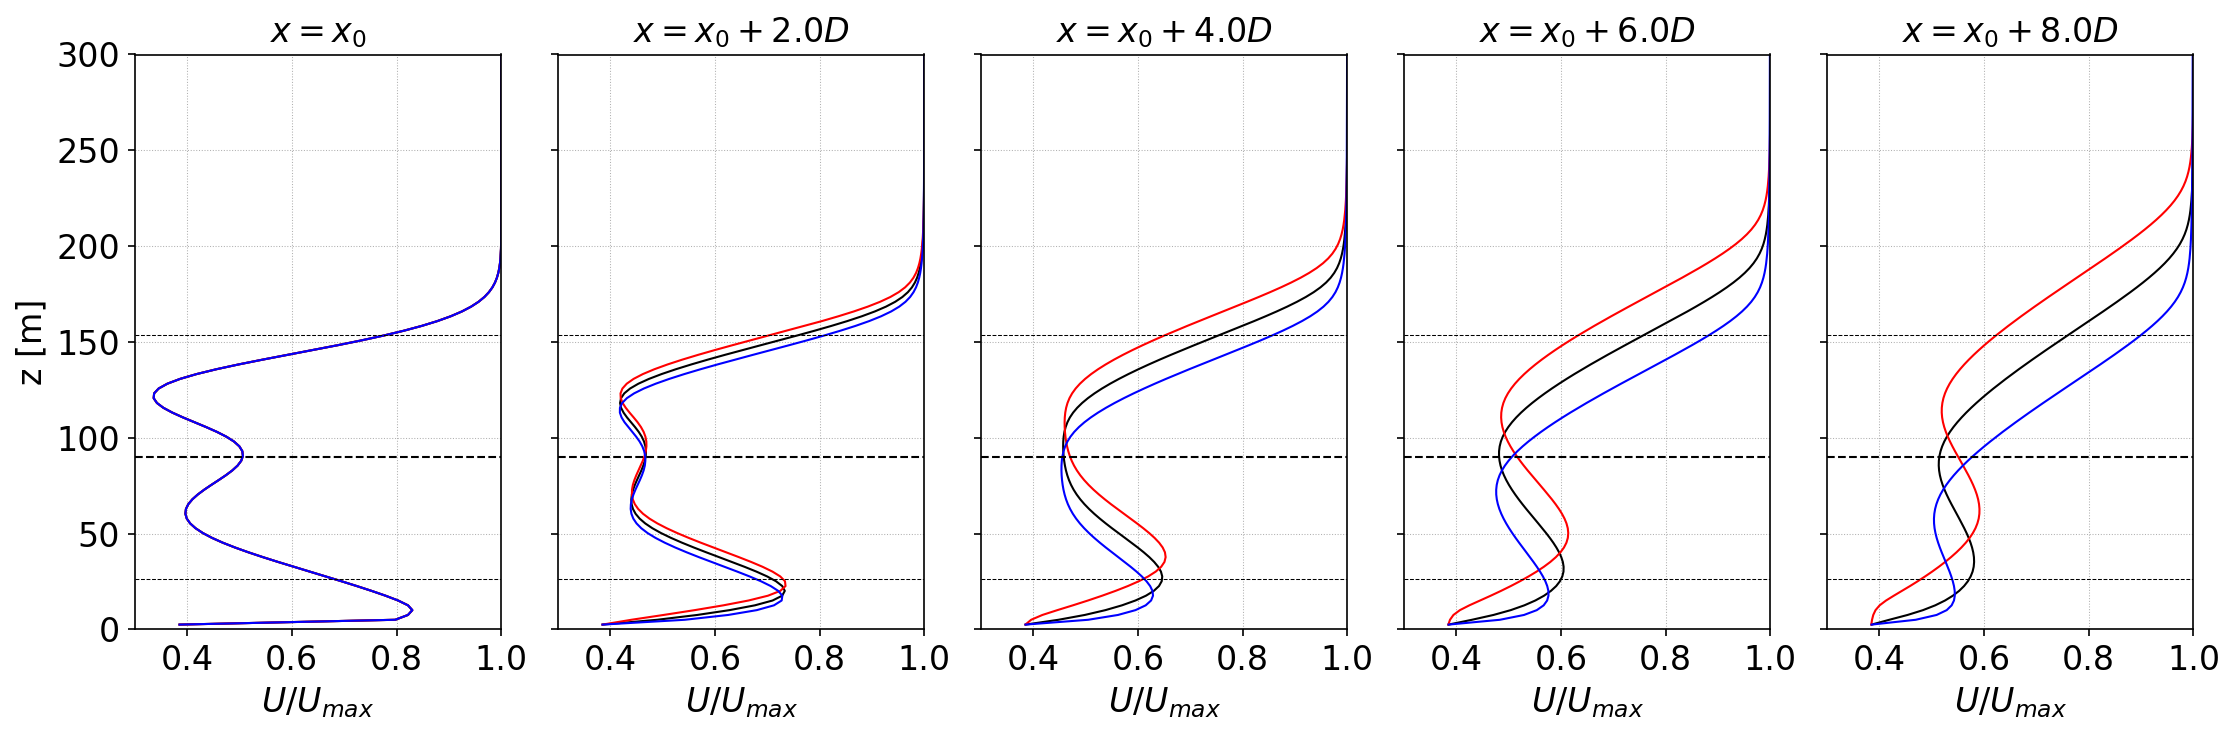

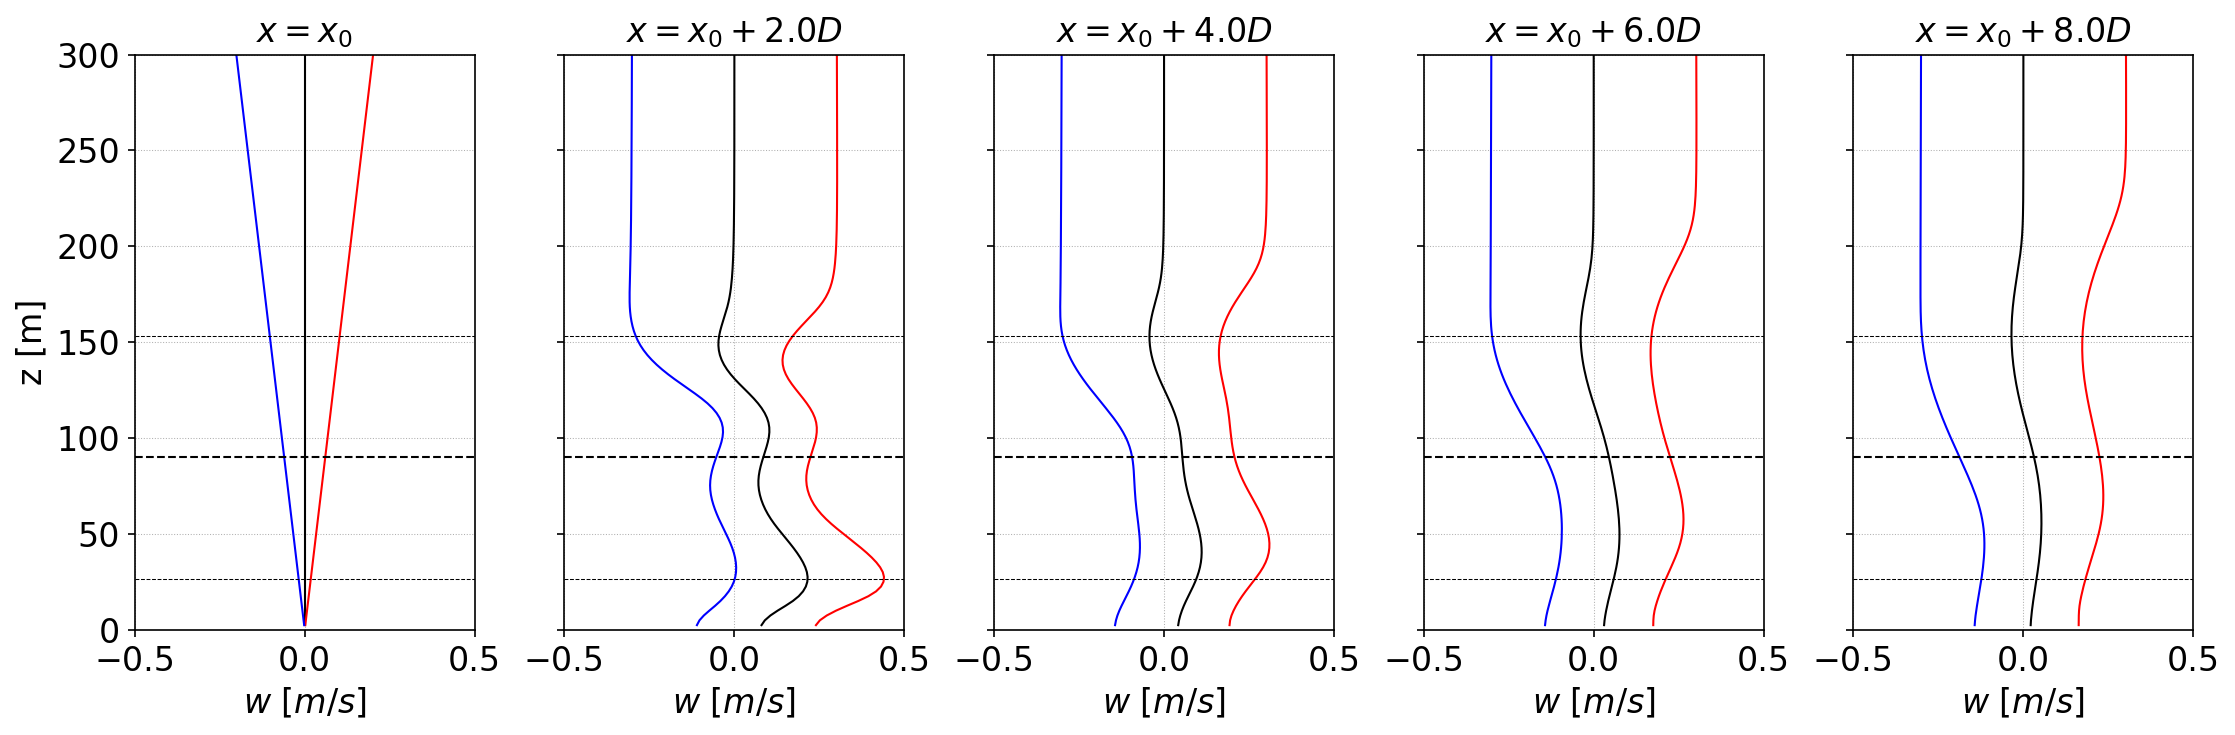

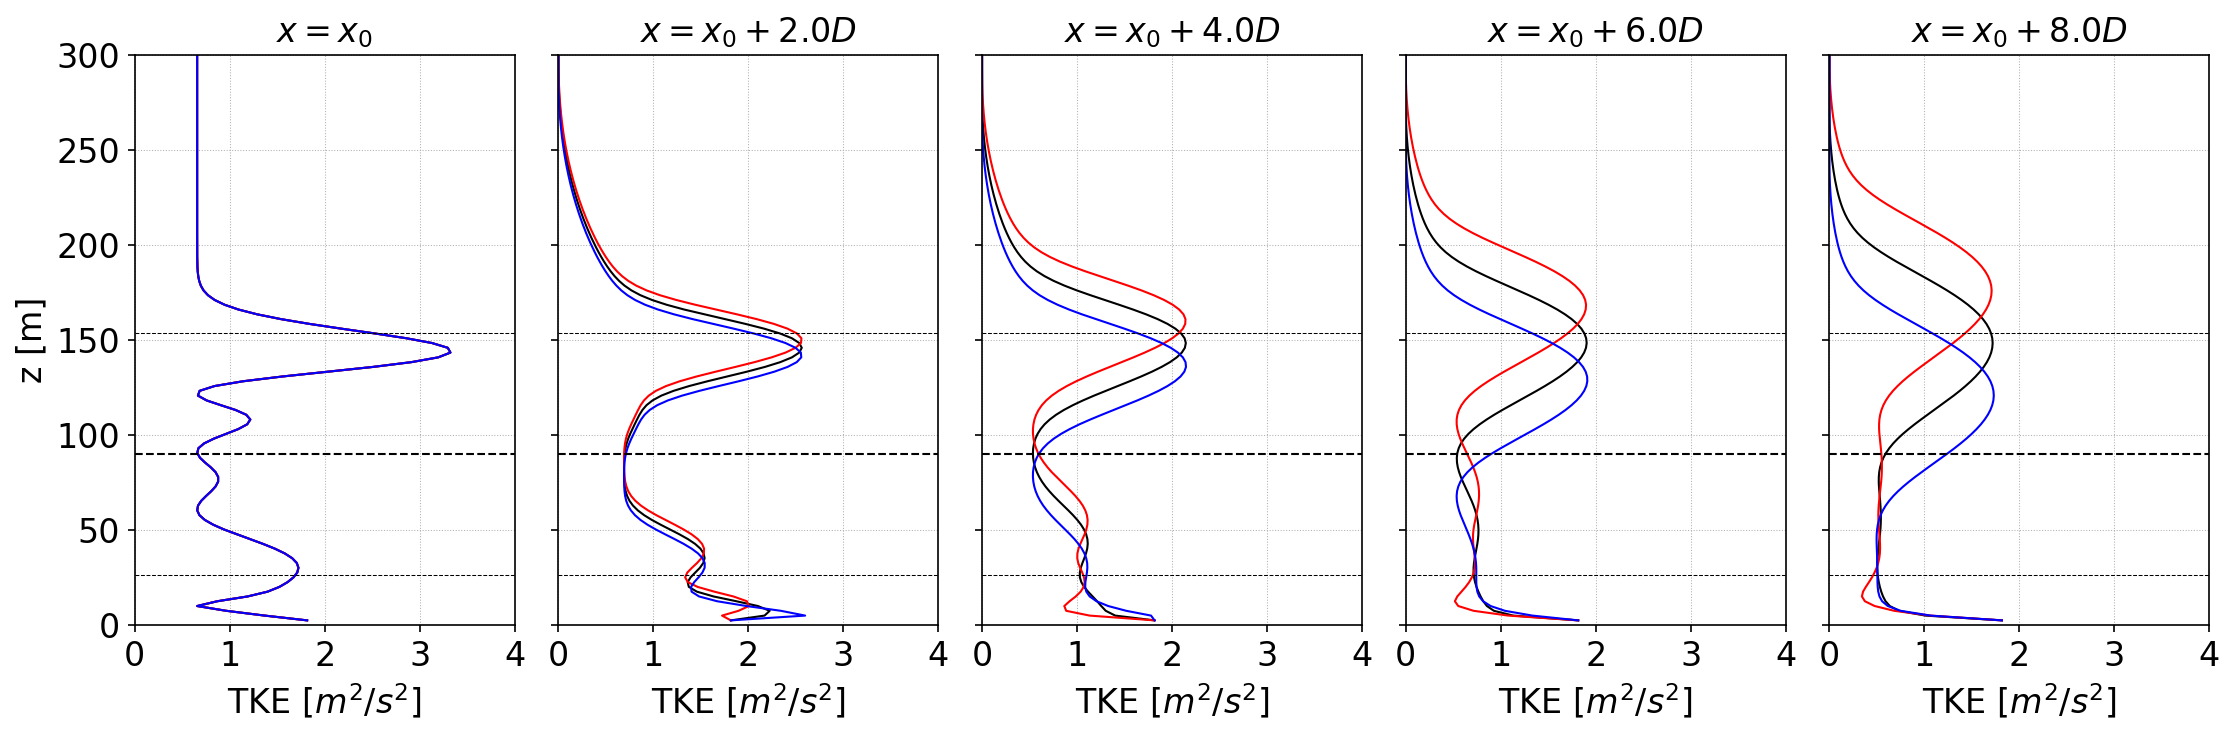

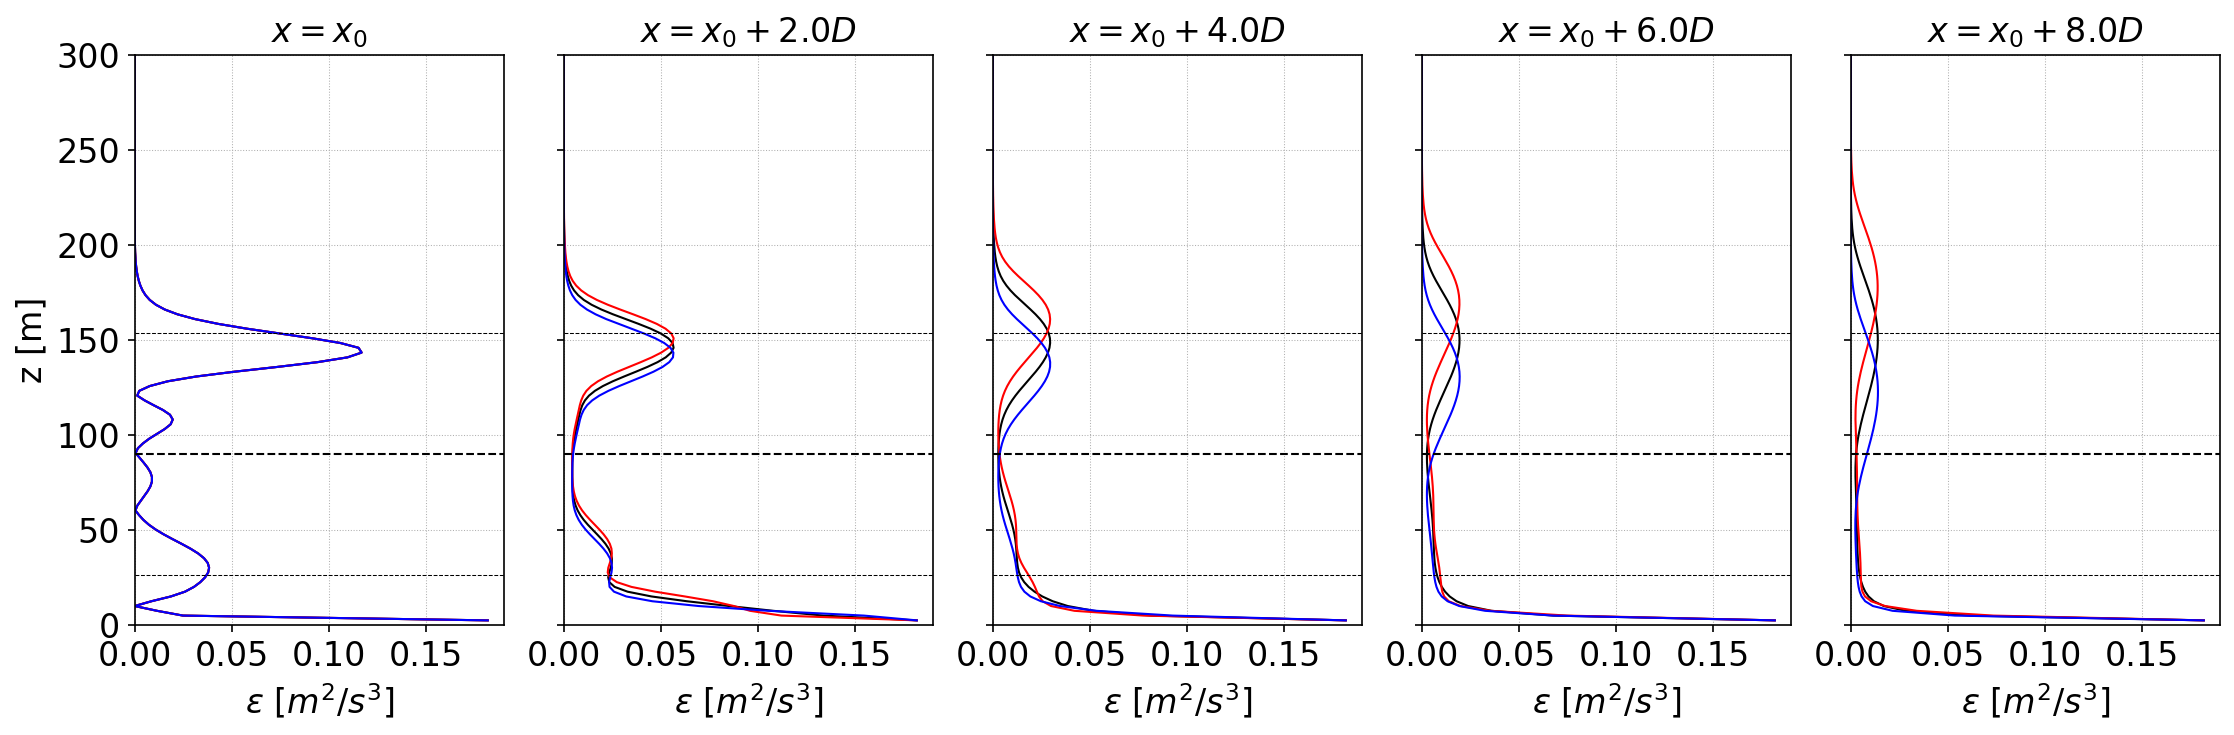

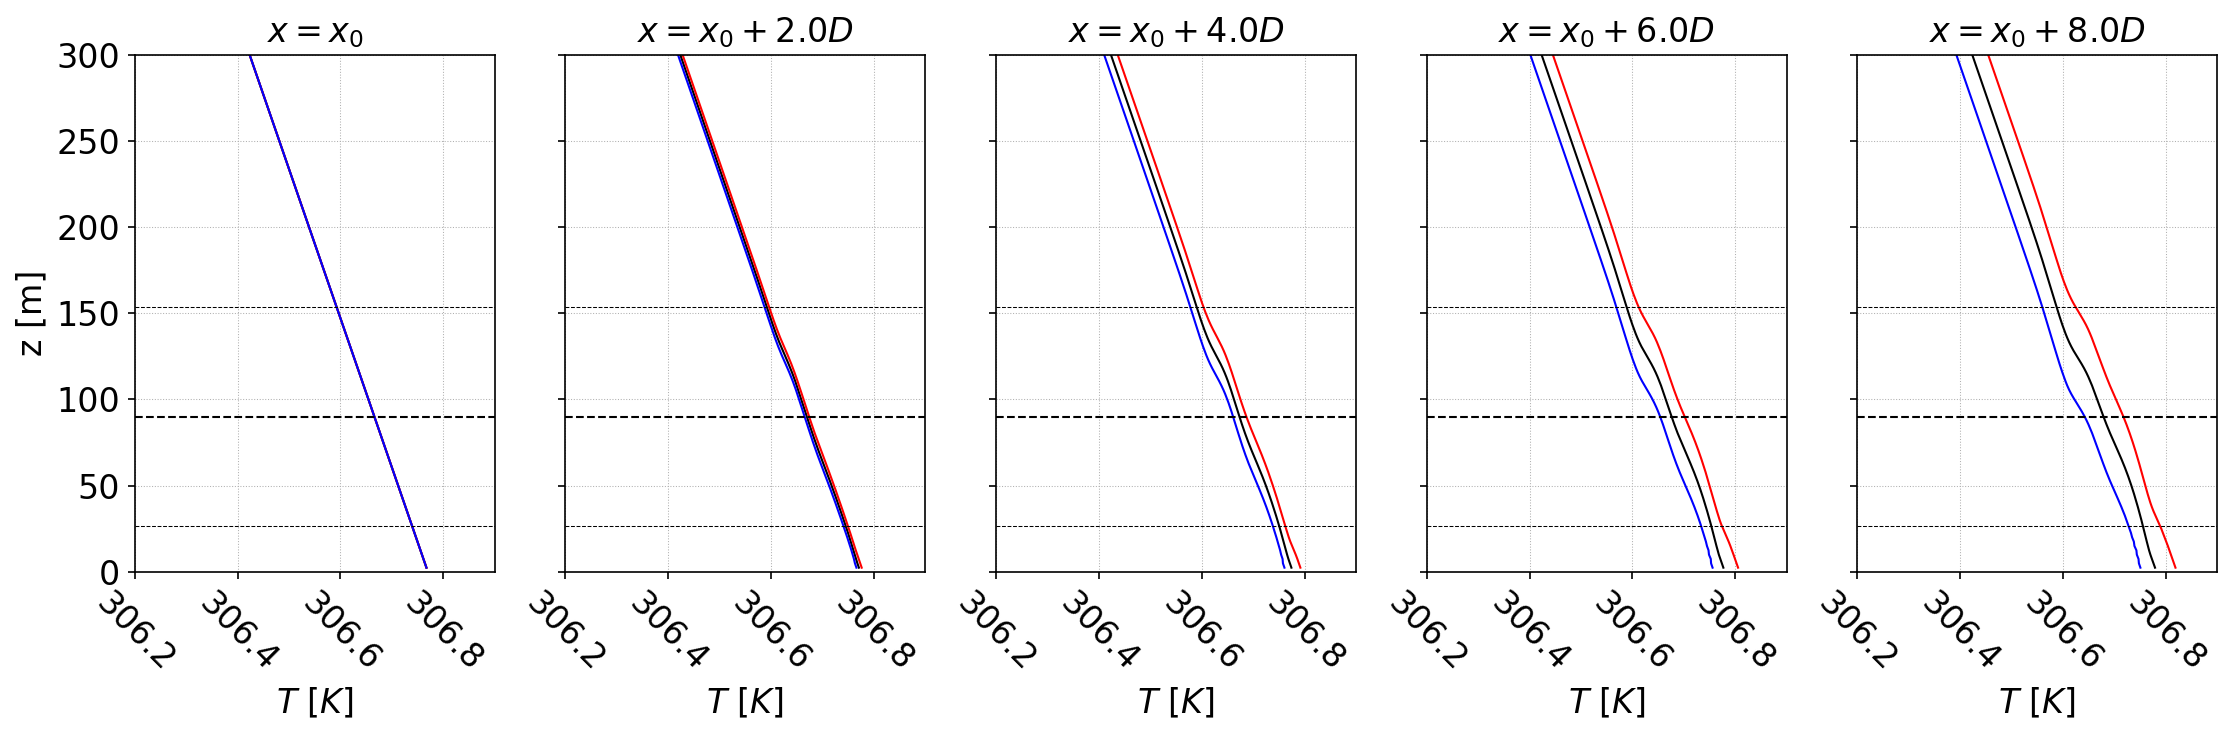

In [24]:
savefigs = True
figdir   = 'JRSE_RANS_figs/'
figname  = 'RANS_profile_{var}.{ext}'

colors ={'flat':'k','down':'blue','up':'red'}
titles = ['u profile','w profile','k profile','e profile','T profile']
titles = ['$U/U_{max}$','$w$ [$m$/$s$]','TKE [$m^2$/$s^2$]','$\\varepsilon$ [$m^2$/$s^3$]','$T$ [$K$]']
lims = {'u':(0.3,1),'w':(-0.5,0.5),'k':(0,4),'e':(0.0,0.19),'T':(306.2,306.9)}
#lims = {'u':(0,10),'w':(-0.5,0.5),'k':(0,4)}
ixvec = np.arange(0,len(xvec_flat))
#xvec_plot = [0,2*D,4*D,6*D,8*D,10*D,25*D]
#xvec_plot = [0,1*D,3*D,5*D,7*D,9*D,10*D]
#xvec_plot = [0,25*D,50*D,75*D,100*D]
#xvec_plot = [0,5*D,10*D,15*D,20*D,25*D]
#xvec_plot = [0,1*D,3*D,5*D,6*D,7*D]
xvec_plot = [0,1*D,3*D,5*D,7*D]
iplot = [np.argmin(np.abs(np.array(xvec_flat)-xval)) for i,xval in enumerate(xvec_plot)]
for iprof,prof in enumerate(Sol_flat):
    fig, axs = plt.subplots(1, len(iplot), figsize=(len(iplot)*3, 5), dpi=150, sharey=True,sharex=True)
    for iplt, i in enumerate(iplot):
        ax = axs[iplt]
        try:
            if prof=='u':
                ax.plot(Sol_flat[prof][i]/np.max(Sol_flat[prof][i]),zvec,c=colors['flat'],lw=1,label='flat')
            else:
                ax.plot(Sol_flat[prof][i],zvec,c=colors['flat'],lw=1,label='flat')
            #ax.plot(zvec,Sol_flat[prof][i],c=colors['flat'],lw=1,label='flat')
        except:
            print("no flat prof")
        try:
            if prof=='u':
                ax.plot(Sol_up[prof][i]/np.max(Sol_up[prof][i]),zvec,c=colors['up'],lw=1,label='updraft')
            else:
                ax.plot(Sol_up[prof][i],zvec,c=colors['up'],lw=1,label='up')

            #ax.plot(zvec,Sol_up[prof][i],c=colors['up'],lw=1,label='updraft')
        except:
            print("no up prof")
        try:
            if prof=='u':
                ax.plot(Sol_down[prof][i]/np.max(Sol_down[prof][i]),zvec,c=colors['down'],lw=1,label='downdraft')
            else:
                ax.plot(Sol_down[prof][i],zvec,c=colors['down'],lw=1,label='down')
            #ax.plot(zvec,Sol_down[prof][i],c=colors['down'],lw=1,label='downdraft')
        except:
            print("no down prof")

        ax.set_xlabel(titles[iprof])
        #ax.set_title("x/D = "+str(5*iplt))
        #ax.set_title("x/D = "+str(xvec_plot[iplt]/D+1))
        if i == 0:
            ax.set_title("$x = x_0$")
        else:
            ax.set_title("$x = x_0 + $"+str(xvec_plot[iplt]/D+1)+"$D$")
        try:
            ax.set_xlim(lims[prof])
            plotrotorlines(ax, zhh, D, lims[prof][0], lims[prof][1], color='k', linestyle='--')
        except:
            print("no lims found")
            #plotrotorlines(ax, zhh, D, lims[][0], lims[prof][1], color='k', linestyle='--')
        ax.set_ylim([0, 300])
        ax.grid(ls=':', lw=0.5)
        #if iplt == 0:
        #    ax.legend()
        if prof=='T':
            ax.tick_params(axis='x', labelrotation=315)
        if prof=='w':
            tick_positions = [-0.5,0,0.5]
            ax.set_xticks(tick_positions)
        setfigtextsize(ax, 16)
    axs[0].set_ylabel('z [m]')
    plt.tight_layout()
    if savefigs:
        for ext in ['png', 'pdf']:
            fname = figdir+'/'+figname.format(var=prof, ext=ext)
            print('Saving '+fname)
            plt.savefig(fname)